# Matrix-Power Indicators — EDA

**Idea:** raise a scalar to a *matrix* power, i.e. `a^M`, where `M` is built from rolling OHLCV.
Symbolic regression / `gplearn` walks the space of scalar→scalar transforms; this walks a *fundamentally different* space because matrices don't commute and have spectra.

**Definition.** For a scalar `a > 0` and a square matrix `M`,

$$a^{M} \;=\; \exp(M \ln a) \;=\; \sum_{k=0}^{\infty} \frac{(M \ln a)^{k}}{k!}.$$

Note that varying `a` only **rescales** `M` inside the exponent, so the genuinely new degree of freedom is *how we build `M`*. We sweep `a` for completeness, but the experimental variation is in the matrix builders.

**Pipeline.**
1. Load ~50 random tickers from `Data/PriceData/`.
2. For each rolling window of OHLCV, build several candidate matrices `M` (covariance, correlation, Hankel, companion, log-return cross-section).
3. Compute `a^M` for several bases.
4. Reduce each `a^M` to scalar features (trace, det, spectral radius, Frobenius norm, top-element, eigenvalue spread).
5. Score each feature against next-day return sign: IC, hit rate, AUC.
6. Compare against trivial baselines (1-day return, 5-day return, realized vol).

**Target:** sign of next-day close-to-close return. Magnitude ignored, per spec.

In [1]:
import os, glob, warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm, fractional_matrix_power
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
np.random.seed(42); random.seed(42)

PRICE_DIR = Path('Data/PriceData')
N_TICKERS = 50          # initial EDA sample
MIN_BARS  = 400         # require at least this many bars per ticker
WINDOW    = 20          # rolling window size for matrix construction

all_files = sorted(PRICE_DIR.glob('*.parquet'))
print(f'{len(all_files)} parquet files available in {PRICE_DIR}')

4265 parquet files available in Data\PriceData


In [2]:
# Sample N_TICKERS that have enough history
def load_ticker(p):
    df = pd.read_parquet(p)
    df = df.sort_values('Date').reset_index(drop=True)
    df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df['Ticker'] = p.stem
    return df

candidate_files = random.sample(all_files, min(len(all_files), 5 * N_TICKERS))
loaded = []
for p in candidate_files:
    try:
        d = load_ticker(p)
        if len(d) >= MIN_BARS and d[['Open','High','Low','Close','Volume']].gt(0).all().all():
            loaded.append(d)
        if len(loaded) >= N_TICKERS:
            break
    except Exception:
        continue

print(f'Loaded {len(loaded)} tickers')
print('Sample tickers:', [d.Ticker.iloc[0] for d in loaded[:10]])
loaded[0].tail(3)

Loaded 50 tickers
Sample tickers: ['COCO', 'AMGN', 'LION', 'IPM', 'HQL', 'DKS', 'CLF', 'CATY', 'SLQT', 'APLS']


,Date,Open,High,Low,Close,Volume,Ticker
669,2026-05-06,68.96,68.96,66.96,68.64,565584.0,COCO
670,2026-05-07,69.15,69.35,67.24,68.20,551097.0,COCO
671,2026-05-08,68.45,72.98,68.32,71.60,1139588.0,COCO


## 1. Matrix builders

Each builder takes a window of OHLCV bars and returns a small square matrix `M`. We deliberately keep `M` small (5×5 or less) so `expm` is fast and eigenvalues stay interpretable.

- **`cov_ohlcv`** — 5×5 covariance of log-returns of (Open, High, Low, Close, Volume). Captures cross-channel co-movement.
- **`corr_ohlcv`** — 5×5 correlation matrix. Same as above but unit-scaled, so spectra are bounded.
- **`hankel_returns`** — d×d Hankel matrix of last `2d-1` close log-returns. Encodes recent return *sequence*; eigenvalues relate to dominant cycles.
- **`companion_ar`** — companion matrix of an AR(d) fit on close returns. `M^k` propagates the AR forward; `expm(M)` is the continuous-time analog.
- **`return_cross`** — 5×5 outer-product-style matrix from the *last* OHLCV log-returns vector. Rank-1 by construction (one nonzero eigenvalue), used as a sanity-check baseline.

In [3]:
def _safe_log_returns(arr):
    """Element-wise log returns, replacing non-finite with 0."""
    arr = np.asarray(arr, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        r = np.diff(np.log(arr), axis=0)
    r[~np.isfinite(r)] = 0.0
    return r

def cov_ohlcv(window):
    """window: shape (W, 5) of [O,H,L,C,V]. Returns 5x5."""
    R = _safe_log_returns(window)
    if R.shape[0] < 2:
        return np.eye(5) * 1e-8
    M = np.cov(R.T)
    return np.nan_to_num(M, nan=0.0, posinf=0.0, neginf=0.0)

def corr_ohlcv(window):
    R = _safe_log_returns(window)
    if R.shape[0] < 2:
        return np.eye(5)
    M = np.corrcoef(R.T)
    return np.nan_to_num(M, nan=0.0, posinf=0.0, neginf=0.0)

def hankel_returns(window, d=5):
    """Hankel of last 2d-1 close log-returns."""
    closes = window[:, 3]
    r = _safe_log_returns(closes.reshape(-1, 1)).ravel()
    need = 2 * d - 1
    if len(r) < need:
        r = np.concatenate([np.zeros(need - len(r)), r])
    r = r[-need:]
    H = np.empty((d, d))
    for i in range(d):
        H[i] = r[i:i+d]
    return H

def companion_ar(window, d=5):
    """Fit AR(d) by least squares on close log-returns; return its companion matrix."""
    closes = window[:, 3]
    r = _safe_log_returns(closes.reshape(-1, 1)).ravel()
    if len(r) < d + 5:
        return np.eye(d) * 0.01
    # Build lag matrix
    T = len(r) - d
    X = np.column_stack([r[d-1-i : d-1-i+T] for i in range(d)])
    y = r[d:]
    try:
        coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    except np.linalg.LinAlgError:
        return np.eye(d) * 0.01
    C = np.zeros((d, d))
    C[0] = coef
    if d > 1:
        C[1:, :-1] = np.eye(d - 1)
    return np.nan_to_num(C, nan=0.0, posinf=0.0, neginf=0.0)

def return_cross(window):
    """Rank-1 outer product of latest OHLCV log-return vector with itself."""
    R = _safe_log_returns(window)
    if R.shape[0] < 1:
        return np.zeros((5, 5))
    v = R[-1]
    return np.outer(v, v)

BUILDERS = {
    'cov':      cov_ohlcv,
    'corr':     corr_ohlcv,
    'hankel':   hankel_returns,
    'companion': companion_ar,
    'crossret': return_cross,
}

# sanity check
win = loaded[0][['Open','High','Low','Close','Volume']].iloc[-WINDOW:].values
for name, fn in BUILDERS.items():
    M = fn(win)
    print(f'{name:10s} shape={M.shape}  ‖M‖_F={np.linalg.norm(M):.4f}  cond≈{np.linalg.cond(M + 1e-9*np.eye(M.shape[0])):.2e}')

cov        shape=(5, 5)  ‖M‖_F=0.4218  cond≈3.36e+03
corr       shape=(5, 5)  ‖M‖_F=3.5887  cond≈8.86e+01
hankel     shape=(5, 5)  ‖M‖_F=0.3737  cond≈1.42e+02
companion  shape=(5, 5)  ‖M‖_F=2.0238  cond≈1.62e+01
crossret   shape=(5, 5)  ‖M‖_F=0.5331  cond≈5.33e+08


## 2. The number-to-matrix-power operator and feature extractors

`a^M = expm(M · ln a)`. For numerical stability on potentially ill-conditioned `M`, we clip the matrix norm before exponentiating — `expm` overflows fast when `‖M·ln a‖` exceeds ~50.

In [4]:
MAX_SCALED_NORM = 30.0

def num_pow_matrix(a, M):
    """Compute a^M = expm(M * ln a). Clips ‖M·ln a‖ to avoid overflow."""
    S = M * np.log(a)
    nrm = np.linalg.norm(S)
    if nrm > MAX_SCALED_NORM:
        S = S * (MAX_SCALED_NORM / nrm)
    try:
        return expm(S)
    except Exception:
        return np.eye(M.shape[0])

def matrix_features(E):
    """Reduce a square matrix to a small dict of scalar features."""
    n = E.shape[0]
    try:
        eig = np.linalg.eigvals(E)
    except np.linalg.LinAlgError:
        eig = np.zeros(n, dtype=complex)
    abs_eig = np.abs(eig)
    feats = {
        'trace':     np.trace(E).real,
        'logdet':    np.log(np.abs(np.linalg.det(E)) + 1e-12),
        'frob':      np.linalg.norm(E, 'fro'),
        'spec_rad':  abs_eig.max() if abs_eig.size else 0.0,
        'spec_gap':  (abs_eig.max() - np.partition(abs_eig, -2)[-2]) if abs_eig.size > 1 else 0.0,
        'eig_phase_std': np.angle(eig).std() if eig.size else 0.0,
        'top_left':  E[0, 0].real if np.iscomplexobj(E) else E[0, 0],
        'sum_abs':   np.abs(E).sum(),
    }
    return feats

# sanity check
M = corr_ohlcv(win)
for a in [np.e, 2.0, 0.5]:
    E = num_pow_matrix(a, M)
    print(f'a={a:.3f}  features =', {k: round(v, 4) for k, v in matrix_features(E).items()})

a=2.718  features = {'trace': np.float64(37.298), 'logdet': np.float64(5.0), 'frob': np.float64(31.1783), 'spec_rad': np.float64(30.996), 'spec_gap': np.float64(28.4381), 'eig_phase_std': np.float64(0.0), 'top_left': np.float64(8.4065), 'sum_abs': np.float64(151.5803)}
a=2.000  features = {'trace': np.float64(16.2128), 'logdet': np.float64(3.4657), 'frob': np.float64(11.161), 'spec_rad': np.float64(10.8067), 'spec_gap': np.float64(8.8893), 'eig_phase_std': np.float64(0.0), 'top_left': np.float64(3.4925), 'sum_abs': np.float64(52.9369)}
a=0.500  features = {'trace': np.float64(3.2248), 'logdet': np.float64(-3.4657), 'frob': np.float64(1.6058), 'spec_rad': np.float64(0.9735), 'spec_gap': np.float64(0.0844), 'eig_phase_std': np.float64(0.0), 'top_left': np.float64(0.6754), 'sum_abs': np.float64(6.0702)}


## 3. Single-ticker walkthrough

Roll across AAPL, build all matrices for each window, compute `a^M` for `a ∈ {e, 2, 0.5}`, and extract features. Plot a few alongside price.

In [5]:
BASES = [np.e, 2.0, 0.5]

def compute_panel(df, window=WINDOW, bases=BASES):
    """For one ticker df, compute the full feature panel.
    Returns DataFrame indexed by the *current* bar (features are causal: window ends at t)."""
    arr = df[['Open','High','Low','Close','Volume']].values
    dates = df['Date'].values
    N = len(arr)
    rows = []
    idx = []
    for t in range(window, N):
        w = arr[t-window:t]
        row = {}
        for bname, bfn in BUILDERS.items():
            M = bfn(w)
            for a in bases:
                E = num_pow_matrix(a, M)
                feats = matrix_features(E)
                a_tag = {np.e: 'e', 2.0: '2', 0.5: 'h'}[a]
                for fk, fv in feats.items():
                    row[f'{bname}_a{a_tag}_{fk}'] = fv
        rows.append(row)
        idx.append(dates[t])
    out = pd.DataFrame(rows, index=pd.DatetimeIndex(idx, name='Date'))
    return out

aapl = next((d for d in loaded if d.Ticker.iloc[0] == 'AAPL'), loaded[0])
print('Walking ticker:', aapl.Ticker.iloc[0], 'bars:', len(aapl))
%time aapl_panel = compute_panel(aapl)
print('Panel shape:', aapl_panel.shape, '(rows × features)')
aapl_panel.iloc[:3, :6]

Walking ticker: COCO bars: 672


CPU times: total: 984 ms
Wall time: 979 ms
Panel shape: (652, 120) (rows × features)


,cov_ae_trace,cov_ae_logdet,cov_ae_frob,cov_ae_spec_rad,cov_ae_spec_gap,cov_ae_eig_phase_std
Date,,,,,,
2023-10-03,5.447720,0.372148,2.467721,1.440651,0.434884,0.0
2023-10-04,5.430241,0.359888,2.457588,1.423351,0.417838,0.0
2023-10-05,5.429582,0.359439,2.457198,1.422643,0.417106,0.0


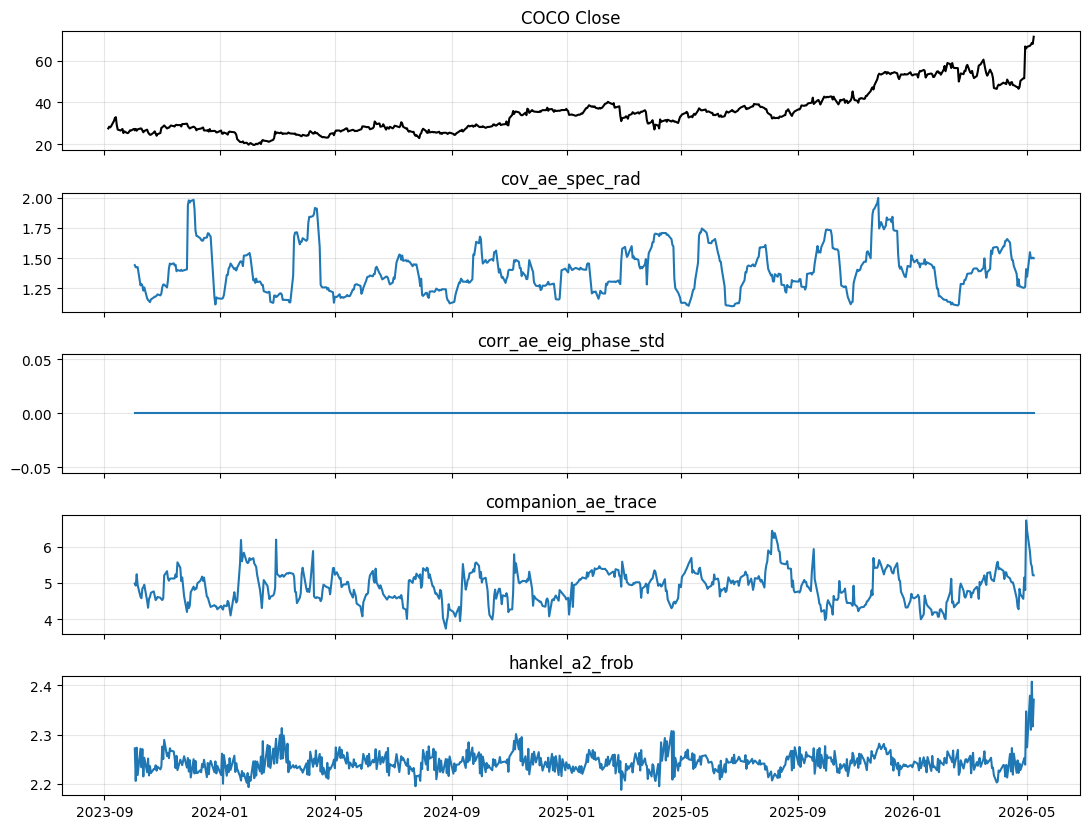

In [6]:
# Plot price + a few representative features
aapl_idx = aapl.set_index(pd.DatetimeIndex(aapl['Date']))
to_plot = [
    'cov_ae_spec_rad',
    'corr_ae_eig_phase_std',
    'companion_ae_trace',
    'hankel_a2_frob',
]
to_plot = [c for c in to_plot if c in aapl_panel.columns]
fig, axes = plt.subplots(len(to_plot) + 1, 1, figsize=(11, 2 + 1.6*len(to_plot)), sharex=True)
axes[0].plot(aapl_idx.index, aapl_idx['Close'], color='black')
axes[0].set_title(f"{aapl.Ticker.iloc[0]} Close"); axes[0].grid(alpha=.3)
for ax, col in zip(axes[1:], to_plot):
    ax.plot(aapl_panel.index, aapl_panel[col])
    ax.set_title(col); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 4. Build the full multi-ticker panel

Compute for all ~50 tickers, attach the binary target (sign of next-day close-to-close return), pool into a long-form table.

In [7]:
def attach_target(panel, df):
    """Attach next-day return + sign target to feature panel."""
    closes = df.set_index(pd.DatetimeIndex(df['Date']))['Close']
    fwd = closes.pct_change().shift(-1)              # tomorrow's return
    panel = panel.copy()
    panel['fwd_ret'] = fwd.reindex(panel.index).values
    panel['fwd_sign'] = (panel['fwd_ret'] > 0).astype(int)
    panel['ticker'] = df['Ticker'].iloc[0]
    return panel.dropna(subset=['fwd_ret'])

from time import time
t0 = time()
panels = []
for i, d in enumerate(loaded):
    p = compute_panel(d)
    p = attach_target(p, d)
    panels.append(p)
    if (i + 1) % 10 == 0:
        print(f'{i+1}/{len(loaded)}  elapsed={time()-t0:.1f}s')
panel = pd.concat(panels, axis=0)
print(f'Total rows: {len(panel):,}   features: {panel.shape[1] - 3}')
panel.head(2)

10/50  elapsed=9.7s


20/50  elapsed=19.0s


30/50  elapsed=28.4s


40/50  elapsed=38.0s


50/50  elapsed=47.3s
Total rows: 31,776   features: 120


,cov_ae_trace,cov_ae_logdet,cov_ae_frob,cov_ae_spec_rad,cov_ae_spec_gap,cov_ae_eig_phase_std,cov_ae_top_left,cov_ae_sum_abs,cov_a2_trace,cov_a2_logdet,...,crossret_ah_logdet,crossret_ah_frob,crossret_ah_spec_rad,crossret_ah_spec_gap,crossret_ah_eig_phase_std,crossret_ah_top_left,crossret_ah_sum_abs,fwd_ret,fwd_sign,ticker
Date,,,,,,,,,,,,,,,,,,,,,
2023-10-03,5.447720,0.372148,2.467721,1.440651,0.434884,0.0,1.001749,5.523343,5.292863,0.257953,...,-0.093794,2.197489,1.0,8.881784e-16,0.0,0.999922,4.945913,0.026336,1,COCO
2023-10-04,5.430241,0.359888,2.457588,1.423351,0.417838,0.0,1.001732,5.505687,5.281998,0.249455,...,-0.115039,2.189628,1.0,2.220446e-16,0.0,0.999693,4.918926,-0.031525,0,COCO


## 5. Predictive power per feature

For each feature column, compute:
- **Spearman IC** vs forward return (rank correlation; robust to non-Gaussian features).
- **AUC** for binary up/down classification.
- **Hit rate** when feature > median predicts up.

We rank features and inspect the top of each list. Anything with |IC| > 0.01 across 50 tickers and ~30k pooled samples is at least nominally non-trivial; we'll compare to baselines next.

In [8]:
feat_cols = [c for c in panel.columns if c not in ('fwd_ret','fwd_sign','ticker')]
print(f'Scoring {len(feat_cols)} features on {len(panel):,} rows...')

y_ret  = panel['fwd_ret'].values
y_sign = panel['fwd_sign'].values

rows = []
for c in feat_cols:
    x = panel[c].values
    mask = np.isfinite(x) & np.isfinite(y_ret)
    if mask.sum() < 1000:
        continue
    xv, yv, ys = x[mask], y_ret[mask], y_sign[mask]
    if np.nanstd(xv) < 1e-12:
        continue
    try:
        ic, _ = spearmanr(xv, yv)
    except Exception:
        ic = np.nan
    try:
        auc = roc_auc_score(ys, xv)
        # symmetrize: a feature predicting *down* is just as useful inverted
        auc_signed = max(auc, 1 - auc)
    except Exception:
        auc, auc_signed = np.nan, np.nan
    med = np.median(xv)
    hit = ys[xv > med].mean() if (xv > med).any() else np.nan
    rows.append({'feature': c, 'ic': ic, 'auc': auc, 'auc_abs': auc_signed,
                 'hit_above_med': hit, 'n': mask.sum()})
scores = pd.DataFrame(rows).set_index('feature').sort_values('auc_abs', ascending=False)
scores.head(15)

Scoring 120 features on 31,776 rows...


,ic,auc,auc_abs,hit_above_med,n
feature,,,,,
cov_ae_top_left,-0.030409,0.477626,0.522374,0.475264,31776
cov_a2_top_left,-0.030488,0.477915,0.522085,0.475642,31776
cov_ah_spec_rad,0.030733,0.521836,0.521836,0.509882,31776
cov_ah_top_left,0.030494,0.521822,0.521822,0.513343,31776
cov_ah_spec_gap,-0.028568,0.480745,0.519255,0.480300,31776
hankel_a2_spec_rad,-0.028101,0.481194,0.518806,0.479607,31776
hankel_ae_spec_rad,-0.028101,0.481194,0.518806,0.479607,31776
hankel_a2_sum_abs,-0.029495,0.481508,0.518492,0.481558,31776
hankel_ae_sum_abs,-0.029449,0.481513,0.518487,0.481684,31776


In [9]:
print('Top by |IC|:')
print(scores.reindex(scores['ic'].abs().sort_values(ascending=False).index).head(10).round(4))
print('\nBottom by AUC (i.e. weakest):')
print(scores.sort_values('auc_abs').head(5).round(4))

Top by |IC|:
                        ic     auc  auc_abs  hit_above_med      n
feature                                                          
cov_ah_spec_rad     0.0307  0.5218   0.5218         0.5099  31776
cov_ah_top_left     0.0305  0.5218   0.5218         0.5133  31776
cov_a2_top_left    -0.0305  0.4779   0.5221         0.4756  31776
cov_ae_top_left    -0.0304  0.4776   0.5224         0.4753  31776
hankel_a2_sum_abs  -0.0295  0.4815   0.5185         0.4816  31776
hankel_ae_sum_abs  -0.0294  0.4815   0.5185         0.4817  31776
cov_ah_spec_gap    -0.0286  0.4807   0.5193         0.4803  31776
hankel_a2_spec_rad -0.0281  0.4812   0.5188         0.4796  31776
hankel_ae_spec_rad -0.0281  0.4812   0.5188         0.4796  31776
hankel_ah_sum_abs  -0.0280  0.4820   0.5180         0.4807  31776

Bottom by AUC (i.e. weakest):
                      ic     auc  auc_abs  hit_above_med      n
feature                                                        
corr_ae_spec_gap -0.0027  0.5001   0

## 6. Baselines

A high-Sharpe-looking IC is meaningless if a 1-day momentum feature does the same thing. Build trivial baselines and score them with the same machinery.

In [10]:
def baseline_panel(df, window=WINDOW):
    closes = df.set_index(pd.DatetimeIndex(df['Date']))['Close']
    vol = df.set_index(pd.DatetimeIndex(df['Date']))['Volume']
    ret1  = closes.pct_change()
    ret5  = closes.pct_change(5)
    ret20 = closes.pct_change(window)
    rv    = ret1.rolling(window).std()
    z     = (closes - closes.rolling(window).mean()) / (closes.rolling(window).std() + 1e-9)
    vchg  = vol.pct_change(5)
    out = pd.DataFrame({'b_ret1': ret1, 'b_ret5': ret5, 'b_ret20': ret20,
                        'b_rv': rv, 'b_zclose': z, 'b_volchg5': vchg})
    return out

base_panels = []
for i, d in enumerate(loaded):
    bp = baseline_panel(d)
    bp = bp.reindex(panels[i].index)
    bp['ticker'] = d.Ticker.iloc[0]
    base_panels.append(bp)
base_panel = pd.concat(base_panels, axis=0)
base_panel = base_panel.join(panel[['fwd_ret', 'fwd_sign']])

rows = []
for c in [c for c in base_panel.columns if c.startswith('b_')]:
    x = base_panel[c].values
    yv = base_panel['fwd_ret'].values
    ys = base_panel['fwd_sign'].values
    m = np.isfinite(x) & np.isfinite(yv)
    ic, _ = spearmanr(x[m], yv[m])
    auc = roc_auc_score(ys[m], x[m])
    rows.append({'feature': c, 'ic': ic, 'auc': auc, 'auc_abs': max(auc, 1-auc)})
baseline_scores = pd.DataFrame(rows).set_index('feature').sort_values('auc_abs', ascending=False)
baseline_scores.round(4)

,ic,auc,auc_abs
feature,,,
b_ret20,-0.0094,0.4948,0.5052
b_zclose,-0.0077,0.4955,0.5045
b_rv,0.0038,0.5023,0.5023
b_ret5,-0.0018,0.4986,0.5014
b_volchg5,-0.0030,0.4998,0.5002
b_ret1,-0.0014,0.5001,0.5001


In [11]:
# Side-by-side: best matrix-power features vs baselines
topN = 10
compare = pd.concat([
    scores[['ic','auc_abs']].head(topN).assign(kind='matrix'),
    baseline_scores[['ic','auc_abs']].assign(kind='baseline'),
]).round(4)
print(compare)

                        ic  auc_abs      kind
feature                                      
cov_ae_top_left    -0.0304   0.5224    matrix
cov_a2_top_left    -0.0305   0.5221    matrix
cov_ah_spec_rad     0.0307   0.5218    matrix
cov_ah_top_left     0.0305   0.5218    matrix
cov_ah_spec_gap    -0.0286   0.5193    matrix
hankel_a2_spec_rad -0.0281   0.5188    matrix
hankel_ae_spec_rad -0.0281   0.5188    matrix
hankel_a2_sum_abs  -0.0295   0.5185    matrix
hankel_ae_sum_abs  -0.0294   0.5185    matrix
hankel_ah_sum_abs  -0.0280   0.5180    matrix
b_ret20            -0.0094   0.5052  baseline
b_zclose           -0.0077   0.5045  baseline
b_rv                0.0038   0.5023  baseline
b_ret5             -0.0018   0.5014  baseline
b_volchg5          -0.0030   0.5002  baseline
b_ret1             -0.0014   0.5001  baseline


## 7. Visualizations: feature distributions and time-stability

Two checks:
1. Feature distribution per outcome class — do up-days and down-days have visibly different feature distributions?
2. Rolling IC of the best feature — is the signal stable across time, or concentrated in a few months?

Best feature by AUC: cov_ae_top_left


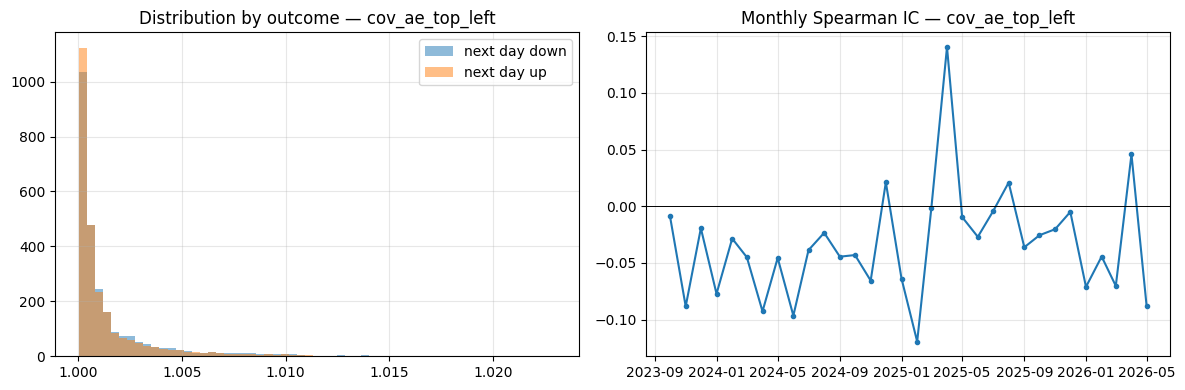

Mean monthly IC: -0.0336  |  std: 0.0492  |  hit-pos: 12.50%


In [12]:
best_feat = scores.index[0]
print('Best feature by AUC:', best_feat)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x_up   = panel.loc[panel['fwd_sign']==1, best_feat].dropna()
x_down = panel.loc[panel['fwd_sign']==0, best_feat].dropna()
lo, hi = np.nanpercentile(panel[best_feat].dropna(), [1, 99])
bins = np.linspace(lo, hi, 60)
axes[0].hist(x_down, bins=bins, alpha=.5, label='next day down', density=True)
axes[0].hist(x_up,   bins=bins, alpha=.5, label='next day up',   density=True)
axes[0].set_title(f'Distribution by outcome — {best_feat}')
axes[0].legend(); axes[0].grid(alpha=.3)

# Rolling monthly IC across pooled time
tmp = panel[[best_feat, 'fwd_ret']].dropna().copy()
tmp['month'] = tmp.index.to_period('M')
monthly_ic = tmp.groupby('month').apply(lambda g: spearmanr(g[best_feat], g['fwd_ret'])[0] if len(g) > 30 else np.nan)
axes[1].plot(monthly_ic.index.to_timestamp(), monthly_ic.values, marker='o', ms=3)
axes[1].axhline(0, color='k', lw=.7)
axes[1].set_title(f'Monthly Spearman IC — {best_feat}')
axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print(f'Mean monthly IC: {monthly_ic.mean():.4f}  |  std: {monthly_ic.std():.4f}  |  hit-pos: {(monthly_ic>0).mean():.2%}')

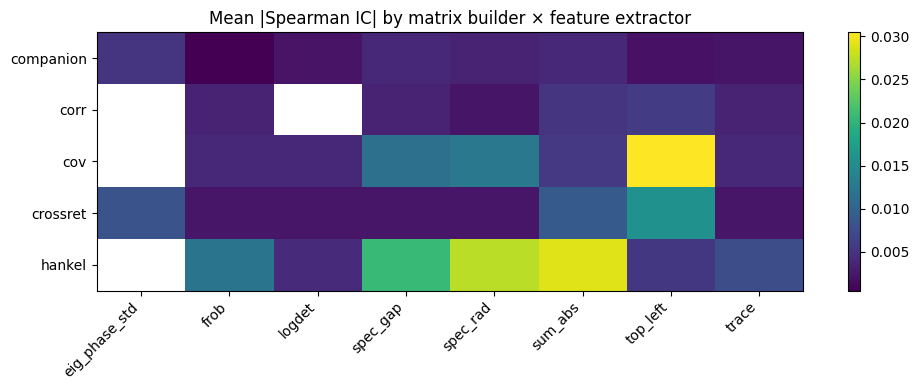

extractor,eig_phase_std,frob,logdet,spec_gap,spec_rad,sum_abs,top_left,trace
builder,,,,,,,,
companion,0.0051,0.0005,0.0020,0.0040,0.0034,0.0040,0.0019,0.0022
corr,NaN,0.0035,NaN,0.0035,0.0023,0.0051,0.0057,0.0035
cov,NaN,0.0040,0.0040,0.0116,0.0125,0.0055,0.0305,0.0040
crossret,0.0081,0.0023,0.0023,0.0023,0.0023,0.0090,0.0156,0.0023
hankel,NaN,0.0120,0.0041,0.0207,0.0274,0.0290,0.0053,0.0076


In [13]:
# Heatmap: avg |IC| by builder × feature-extractor (collapsed across base a)
score_meta = scores.copy()
score_meta['builder']   = score_meta.index.str.split('_').str[0]
score_meta['extractor'] = score_meta.index.str.split('_').str[2:].str.join('_')
pivot = score_meta.pivot_table(index='builder', columns='extractor', values='ic', aggfunc=lambda s: np.nanmean(np.abs(s)))
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
ax.set_title('Mean |Spearman IC| by matrix builder × feature extractor')
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()
pivot.round(4)

## 9. Random matrix-builder search

The fixed builders in section 1 cover a few obvious shapes. Now sweep the wider space: build the matrix from **random combinations of OHLCV-derived primitives**.

**Primitives** (14 of them, all tanh-clipped to keep entries roughly in [-1, 1] so expm stays well-conditioned): log returns, log volume changes, candle range / body / wicks, realized vol, z-scored close & volume, return skew/kurt, 5d & 20d momentum, sign of last return.

**Random builder.** For each of N trials, sample two arrays of shape (d, d): an integer index into the primitive list and a sign in {-1, +1}. The builder maps each row's primitive vector to a d x d matrix:  `M[i,j] = sign[i,j] * primitive[idx[i,j]]`. Apply `expm`, extract scalar features as before.

Threshold for keeping a feature for further work: **|Spearman IC| >= 0.05** (about 9 standard errors at N=32k rows, well above what 600 random tests would produce by chance under the null).

In [14]:
def primitives_panel(df, window=WINDOW):
    df = df.sort_values('Date').set_index(pd.DatetimeIndex(df['Date']))
    O, H, L, C, V = (df[c].astype(float) for c in ['Open','High','Low','Close','Volume'])
    log_ret  = np.log(C).diff()
    log_vol  = np.log(V.replace(0, np.nan)).diff()
    range_pct  = (H - L) / C
    body_pct   = (C - O) / C
    upper_wick = (H - np.maximum(O, C)) / C
    lower_wick = (np.minimum(O, C) - L) / C
    rv       = log_ret.rolling(window).std()
    z_close  = (C - C.rolling(window).mean()) / (C.rolling(window).std() + 1e-9)
    z_vol    = (V - V.rolling(window).mean()) / (V.rolling(window).std() + 1e-9)
    skew     = log_ret.rolling(window).skew()
    kurt     = log_ret.rolling(window).kurt()
    mom5     = np.log(C / C.shift(5))
    mom20    = np.log(C / C.shift(window))
    sign_last = np.sign(log_ret)
    out = pd.DataFrame({
        'log_ret': log_ret, 'log_vol': log_vol,
        'range_pct': range_pct, 'body_pct': body_pct,
        'upper_wick': upper_wick, 'lower_wick': lower_wick,
        'rv': rv, 'z_close': z_close, 'z_vol': z_vol,
        'skew': skew, 'kurt': kurt, 'mom5': mom5, 'mom20': mom20,
        'sign_last': sign_last,
    })
    return out

# Build per-ticker primitives aligned to the existing per-ticker panel index, then concat in same order as `panel`.
prim_per_ticker = []
for i, df in enumerate(loaded):
    pp = primitives_panel(df, WINDOW)
    pp = pp.reindex(panels[i].index)
    prim_per_ticker.append(pp)
prim_full = pd.concat(prim_per_ticker, axis=0)
assert len(prim_full) == len(panel), (len(prim_full), len(panel))

# Normalize: divide each primitive by its panel-wide std, tanh-clip to keep entries bounded.
prim_arr = prim_full.values.astype(np.float64)
scales = np.nanstd(prim_arr, axis=0)
scales = np.where(scales > 0, scales, 1.0)
prim_norm = np.tanh(prim_arr / scales)
prim_norm = np.nan_to_num(prim_norm, nan=0.0, posinf=0.0, neginf=0.0)

P_NAMES = list(prim_full.columns)
N_P = len(P_NAMES)
print(f'Primitives panel shape: {prim_norm.shape}')
print(f'Primitive names ({N_P}): {P_NAMES}')
print('Per-primitive (mean, std) after tanh:')
for n, m, s in zip(P_NAMES, prim_norm.mean(0), prim_norm.std(0)):
    print(f'  {n:12s} mean={m:+.3f} std={s:.3f}')

Primitives panel shape: (31776, 14)
Primitive names (14): ['log_ret', 'log_vol', 'range_pct', 'body_pct', 'upper_wick', 'lower_wick', 'rv', 'z_close', 'z_vol', 'skew', 'kurt', 'mom5', 'mom20', 'sign_last']
Per-primitive (mean, std) after tanh:
  log_ret      mean=-0.003 std=0.457
  log_vol      mean=-0.012 std=0.565
  range_pct    mean=+0.559 std=0.257
  body_pct     mean=-0.017 std=0.484
  upper_wick   mean=+0.334 std=0.296
  lower_wick   mean=+0.414 std=0.324
  rv           mean=+0.629 std=0.232
  z_close      mean=+0.029 std=0.660
  z_vol        mean=-0.093 std=0.572
  skew         mean=+0.038 std=0.575
  kurt         mean=+0.291 std=0.414
  mom5         mean=+0.002 std=0.468
  mom20        mean=+0.001 std=0.492
  sign_last    mean=+0.007 std=0.758


In [15]:
# Random matrix-builder search
from time import time

N_RANDOM = 150
D = 4
EXTRACT_NAMES = ['trace', 'logdet', 'frob', 'spec_rad', 'sum_abs', 'top_left']
rng = np.random.default_rng(123)

builders_idx  = rng.integers(0, N_P, size=(N_RANDOM, D, D))
builders_sign = rng.choice([-1.0, 1.0], size=(N_RANDOM, D, D))

N_ROWS = prim_norm.shape[0]
N_FEAT = len(EXTRACT_NAMES)
results = np.empty((N_RANDOM, N_ROWS, N_FEAT), dtype=np.float64)

def extract_vec(E):
    try:
        eig = np.linalg.eigvals(E)
        spec_rad = float(np.abs(eig).max())
    except np.linalg.LinAlgError:
        spec_rad = 0.0
    try:
        det = np.linalg.det(E)
    except np.linalg.LinAlgError:
        det = 0.0
    return (
        float(np.trace(E).real),
        float(np.log(np.abs(det) + 1e-12)),
        float(np.linalg.norm(E, 'fro')),
        spec_rad,
        float(np.abs(E).sum()),
        float(E[0,0].real if np.iscomplexobj(E) else E[0,0]),
    )

t0 = time()
for r in range(N_RANDOM):
    idx = builders_idx[r]
    sgn = builders_sign[r]
    M_all = sgn[None, :, :] * prim_norm[:, idx]   # shape (N_ROWS, D, D)
    for t in range(N_ROWS):
        try:
            E = expm(M_all[t])
        except Exception:
            E = np.eye(D)
        results[r, t, :] = extract_vec(E)
    if (r+1) % 25 == 0:
        print(f'{r+1}/{N_RANDOM}  elapsed={time()-t0:.1f}s')
print(f'done in {time()-t0:.1f}s')

25/150  elapsed=47.3s


50/150  elapsed=96.2s


75/150  elapsed=143.6s


100/150  elapsed=189.6s


125/150  elapsed=235.7s


150/150  elapsed=281.6s
done in 281.6s


In [16]:
# Score each (builder, extractor) feature against forward return
y_ret  = panel['fwd_ret'].values
y_sign = panel['fwd_sign'].values

rows = []
for r in range(N_RANDOM):
    for ei, ename in enumerate(EXTRACT_NAMES):
        x = results[r, :, ei]
        m = np.isfinite(x) & np.isfinite(y_ret)
        if m.sum() < 1000 or np.nanstd(x[m]) < 1e-12:
            continue
        try:
            ic, _ = spearmanr(x[m], y_ret[m])
            auc   = roc_auc_score(y_sign[m], x[m])
        except Exception:
            continue
        rows.append({'builder_id': r, 'extractor': ename,
                     'ic': ic, 'auc': auc, 'auc_abs': max(auc, 1-auc)})
rand_scores = pd.DataFrame(rows)
rand_scores['abs_ic'] = rand_scores['ic'].abs()
rand_scores = rand_scores.sort_values('abs_ic', ascending=False)

thresh = 0.05
winners = rand_scores[rand_scores['abs_ic'] >= thresh].copy()
print(f'Total scored: {len(rand_scores)}  |  features with |IC|>={thresh}: {len(winners)}')
print()
print('Top 20 by |IC|:')
print(rand_scores.head(20).round(4).to_string())

Total scored: 900  |  features with |IC|>=0.05: 31

Top 20 by |IC|:
     builder_id extractor      ic     auc  auc_abs  abs_ic
229          38    logdet  0.0649  0.5314   0.5314  0.0649
181          30    logdet  0.0599  0.5270   0.5270  0.0599
34            5   sum_abs -0.0584  0.4729   0.5271  0.0584
52            8   sum_abs -0.0574  0.4703   0.5297  0.0574
32            5      frob -0.0572  0.4741   0.5259  0.0572
50            8      frob -0.0560  0.4709   0.5291  0.0560
677         112  top_left  0.0550  0.5258   0.5258  0.0550
768         128     trace -0.0546  0.4725   0.5275  0.0546
223          37    logdet -0.0546  0.4716   0.5284  0.0546
512          85      frob -0.0545  0.4752   0.5248  0.0545
314          52      frob -0.0543  0.4735   0.5265  0.0543
49            8    logdet -0.0542  0.4739   0.5261  0.0542
149          24  top_left -0.0541  0.4707   0.5293  0.0541
721         120    logdet  0.0531  0.5241   0.5241  0.0531
533          88  top_left  0.0531  0.5228   0.5

In [17]:
# Decode each interesting recipe back to human-readable form
def decode_recipe(builder_id):
    idx = builders_idx[builder_id]
    sgn = builders_sign[builder_id]
    grid = []
    for i in range(D):
        row = []
        for j in range(D):
            sign_str = '+' if sgn[i,j] > 0 else '-'
            row.append(f'{sign_str}{P_NAMES[idx[i,j]]}')
        grid.append(row)
    return grid

if len(winners) == 0:
    print(f'No features cleared |IC|>={thresh}. Best so far:')
    print(rand_scores.head(5).round(4).to_string())
    print()
    print('Decoded recipe of current best:')
    for row in decode_recipe(int(rand_scores.iloc[0]['builder_id'])):
        print('  ' + ' | '.join(f'{c:>14s}' for c in row))
else:
    print(f'{len(winners)} winning (builder, extractor) pairs.')
    print('\nTop winners:')
    print(winners.head(20).round(4).to_string())
    print()
    for _, w in winners.head(5).iterrows():
        print(f'\n--- builder {int(w.builder_id)} | {w.extractor} | IC={w.ic:+.4f} | AUC={w.auc:.4f} ---')
        for row in decode_recipe(int(w.builder_id)):
            print('  ' + ' | '.join(f'{c:>14s}' for c in row))

31 winning (builder, extractor) pairs.

Top winners:
     builder_id extractor      ic     auc  auc_abs  abs_ic
229          38    logdet  0.0649  0.5314   0.5314  0.0649
181          30    logdet  0.0599  0.5270   0.5270  0.0599
34            5   sum_abs -0.0584  0.4729   0.5271  0.0584
52            8   sum_abs -0.0574  0.4703   0.5297  0.0574
32            5      frob -0.0572  0.4741   0.5259  0.0572
50            8      frob -0.0560  0.4709   0.5291  0.0560
677         112  top_left  0.0550  0.5258   0.5258  0.0550
768         128     trace -0.0546  0.4725   0.5275  0.0546
223          37    logdet -0.0546  0.4716   0.5284  0.0546
512          85      frob -0.0545  0.4752   0.5248  0.0545
314          52      frob -0.0543  0.4735   0.5265  0.0543
49            8    logdet -0.0542  0.4739   0.5261  0.0542
149          24  top_left -0.0541  0.4707   0.5293  0.0541
721         120    logdet  0.0531  0.5241   0.5241  0.0531
533          88  top_left  0.0531  0.5228   0.5228  0.0531
305

## 10. Bigger search: d in {4, 5}, raw + symmetric + skew variants

Section 9 used 150 builders at d=4 and found 31 features with |IC| >= 0.05. Now widen the net:

- **More builders.** 500 random builders at d=4, 250 at d=5.
- **Three matrix variants per builder.**
  - `raw`  : M itself
  - `sym`  : (M + M^T)/2 -- eigenvalues real, exp(M) is positive-definite
  - `skew` : (M - M^T)/2 -- eigenvalues pure imaginary, exp(M) is a rotation matrix (eigenvalues on unit circle). Orthogonal feature space to raw.
- **Faster expm.** Replace the per-row `scipy.linalg.expm` call with a batched scaling-and-squaring Taylor implementation that processes all ~32k rows in one numpy op. Sanity-check against scipy first.

In [18]:
def expm_batch(M_batch, K=16):
    """Vectorized matrix exponential via scaling+squaring with Taylor expansion.
    M_batch: shape (N, D, D). Returns shape (N, D, D)."""
    N, D, _ = M_batch.shape
    norms = np.linalg.norm(M_batch, ord='fro', axis=(1, 2))
    nmax = float(norms.max()) if norms.size else 0.0
    s = max(0, int(np.ceil(np.log2(max(nmax, 1e-9)))))
    scale = 2.0 ** s
    M_s = M_batch / scale
    I = np.broadcast_to(np.eye(D, dtype=M_batch.dtype), (N, D, D)).copy()
    result = I.copy()
    term = I.copy()
    for k in range(1, K + 1):
        term = (term @ M_s) / k
        result = result + term
    for _ in range(s):
        result = result @ result
    return result

def extract_batch(E_batch):
    """Vectorized feature extraction. Returns (N, 7) and the names."""
    N, D, _ = E_batch.shape
    trace_v   = E_batch.trace(axis1=1, axis2=2).real
    det_v     = np.linalg.det(E_batch)
    logdet_v  = np.log(np.abs(det_v) + 1e-12)
    frob_v    = np.linalg.norm(E_batch, axis=(1, 2))
    eig_v     = np.linalg.eigvals(E_batch)
    spec_rad  = np.abs(eig_v).max(axis=1)
    phase_std = np.angle(eig_v).std(axis=1)
    sum_abs   = np.abs(E_batch).sum(axis=(1, 2))
    top_left  = E_batch[:, 0, 0].real
    feats = np.column_stack([trace_v, logdet_v, frob_v, spec_rad, phase_std, sum_abs, top_left])
    names = ['trace', 'logdet', 'frob', 'spec_rad', 'phase_std', 'sum_abs', 'top_left']
    return feats, names

# Sanity check expm_batch vs scipy on a few random matrices
_test = np.random.RandomState(0).randn(20, 4, 4) * 0.7
_E_mine = expm_batch(_test)
_E_scipy = np.array([expm(m) for m in _test])
_diff = np.abs(_E_mine - _E_scipy).max()
print(f'expm_batch max abs diff vs scipy: {_diff:.2e} (should be < 1e-8)')
assert _diff < 1e-6, 'expm_batch accuracy regression'

# Sanity check on extreme-norm matrix
_extreme = (np.random.RandomState(1).randn(5, 5, 5) * 1.5)
_diff_x = np.abs(expm_batch(_extreme) - np.array([expm(m) for m in _extreme])).max()
print(f'expm_batch max abs diff (||M|| ~ 7): {_diff_x:.2e}')

expm_batch max abs diff vs scipy: 3.29e-14 (should be < 1e-8)
expm_batch max abs diff (||M|| ~ 7): 2.49e-12


In [19]:
from time import time

VARIANTS = ['raw', 'sym', 'skew']
EXTRACT_NAMES_BIG = ['trace', 'logdet', 'frob', 'spec_rad', 'phase_std', 'sum_abs', 'top_left']

def make_variant(M_all, kind):
    if kind == 'raw':  return M_all
    if kind == 'sym':  return 0.5 * (M_all + M_all.transpose(0, 2, 1))
    if kind == 'skew': return 0.5 * (M_all - M_all.transpose(0, 2, 1))
    raise ValueError(kind)

rng_big = np.random.default_rng(456)

def random_builders_for(D, N):
    return (rng_big.integers(0, N_P, size=(N, D, D)),
            rng_big.choice([-1.0, 1.0], size=(N, D, D)))

y_ret  = panel['fwd_ret'].values
y_sign = panel['fwd_sign'].values
y_mask = np.isfinite(y_ret)

CONFIGS = [(4, 500), (5, 250)]
all_results = []

for D, N_RAND in CONFIGS:
    print(f'\n=== d={D}, builders={N_RAND} ===')
    idxs, sgns = random_builders_for(D, N_RAND)
    t0 = time()
    for r in range(N_RAND):
        M_all = sgns[r][None, :, :] * prim_norm[:, idxs[r]]   # (N_ROWS, D, D)
        for variant in VARIANTS:
            Mv = make_variant(M_all, variant)
            try:
                Ev = expm_batch(Mv)
            except Exception:
                continue
            feats, fnames = extract_batch(Ev)
            for ei, ename in enumerate(fnames):
                x = feats[:, ei]
                m = y_mask & np.isfinite(x)
                if m.sum() < 1000 or np.nanstd(x[m]) < 1e-12:
                    continue
                try:
                    ic, _ = spearmanr(x[m], y_ret[m])
                    auc   = roc_auc_score(y_sign[m], x[m])
                except Exception:
                    continue
                all_results.append({
                    'd': D, 'builder_id': r, 'variant': variant, 'extractor': ename,
                    'ic': ic, 'auc': auc, 'auc_abs': max(auc, 1 - auc),
                })
        if (r + 1) % 50 == 0:
            print(f'  {r+1}/{N_RAND}  elapsed={time()-t0:.1f}s  features so far: {len(all_results)}')
    print(f'  d={D} done in {time()-t0:.1f}s')

big_scores = pd.DataFrame(all_results)
big_scores['abs_ic'] = big_scores['ic'].abs()
big_scores = big_scores.sort_values('abs_ic', ascending=False).reset_index(drop=True)

print(f'\nTotal scored features: {len(big_scores):,}')
for thr in [0.05, 0.06, 0.07, 0.08, 0.10]:
    print(f'  |IC| >= {thr}: {(big_scores.abs_ic >= thr).sum()}')

# Save artifacts so we can fine-tune downstream
np.savez('Data/EDA/matrix_power_search.npz',
         d4_idx=random_builders_for.__defaults__ if False else np.array([]))  # placeholder
print('\nTop 25:')
print(big_scores.head(25).round(4).to_string())


=== d=4, builders=500 ===


  50/500  elapsed=21.4s  features so far: 850


  100/500  elapsed=42.9s  features so far: 1700


  150/500  elapsed=64.3s  features so far: 2550


  200/500  elapsed=85.7s  features so far: 3398


...

  50/250  elapsed=31.8s  features so far: 9344


  100/250  elapsed=64.5s  features so far: 10194


  150/250  elapsed=95.7s  features so far: 11044


  200/250  elapsed=127.0s  features so far: 11894


  250/250  elapsed=158.1s  features so far: 12744
  d=5 done in 158.1s

Total scored features: 12,744
  |IC| >= 0.05: 309
  |IC| >= 0.06: 40
  |IC| >= 0.07: 4
  |IC| >= 0.08: 0
  |IC| >= 0.1: 0

Top 25:
    d  builder_id variant extractor      ic     auc  auc_abs  abs_ic
0   5          12     sym    logdet  0.0707  0.5352   0.5352  0.0707
1   5          12     raw    logdet  0.0707  0.5352   0.5352  0.0707
2   4         185     sym     trace -0.0705  0.4653   0.5347  0.0705
3   4          65     sym      frob -0.0703  0.4667   0.5333  0.0703
4   4          65     sym     trace -0.0697  0.4675   0.5325  0.0697
5   4          65     raw      frob -0.0694  0.4675   0.5325  0.0694
6   4          65     raw   sum_abs -0.0680  0.4678   0.5322  0.0680
7   4          65     sym  spec_rad -0.0673  0.4683   0.5317  0.0673
8   5          39     raw    logdet -0.0669  0.4663   0.5337  0.0669
9   5          39     sym    logdet -0.0669  0.4663   0.5337  0.0669
10  4         185     sym      frob -0

In [20]:
# Where do the winners live? Break down by (d, variant, extractor)
print('Mean |IC| by (d, variant):')
print(big_scores.groupby(['d', 'variant'])['abs_ic'].agg(['mean', 'max', 'count']).round(4))

print('\nMean |IC| by (variant, extractor):')
piv = big_scores.pivot_table(index='variant', columns='extractor', values='abs_ic', aggfunc='mean')
print(piv.round(4))

print('\n# winners (|IC|>=0.05) by (d, variant, extractor):')
w = big_scores[big_scores.abs_ic >= 0.05]
print(w.groupby(['d', 'variant', 'extractor']).size().unstack(fill_value=0))

Mean |IC| by (d, variant):
             mean     max  count
d variant                       
4 raw      0.0204  0.0694   3497
  skew     0.0199  0.0611   2000
  sym      0.0227  0.0705   2997
5 raw      0.0210  0.0707   1750
  skew     0.0223  0.0575   1000
  sym      0.0236  0.0707   1500

Mean |IC| by (variant, extractor):
extractor    frob  logdet  phase_std  spec_rad  sum_abs  top_left   trace
variant                                                                  
raw        0.0228  0.0229     0.0170    0.0187   0.0227    0.0213  0.0191
skew          NaN     NaN     0.0239       NaN   0.0159    0.0192  0.0238
sym        0.0234  0.0229        NaN    0.0226   0.0224    0.0235  0.0233

# winners (|IC|>=0.05) by (d, variant, extractor):
extractor  frob  logdet  phase_std  spec_rad  sum_abs  top_left  trace
d variant                                                             
4 raw        10      24          1         4       11        14      2
  skew        0       0          6    

In [21]:
# Decode the top recipes. We need to look up the right idx/sgn arrays for each (d, builder_id).
# Re-derive deterministically with the same seed.
import collections

def make_decoder():
    rng_d = np.random.default_rng(456)
    builders = {}
    for D, N_RAND in CONFIGS:
        idx = rng_d.integers(0, N_P, size=(N_RAND, D, D))
        sgn = rng_d.choice([-1.0, 1.0], size=(N_RAND, D, D))
        builders[D] = (idx, sgn)
    return builders

decoder = make_decoder()

def show_recipe(d, builder_id):
    idx, sgn = decoder[d]
    grid = []
    for i in range(d):
        row = []
        for j in range(d):
            sign_str = '+' if sgn[builder_id, i, j] > 0 else '-'
            row.append(f'{sign_str}{P_NAMES[idx[builder_id, i, j]]}')
        grid.append(row)
    return grid

print('Top 10 recipes:')
for k, w in big_scores.head(10).iterrows():
    print(f'\n#{k+1}  d={int(w.d)}  builder={int(w.builder_id)}  variant={w.variant:5s}  extractor={w.extractor:9s}  IC={w.ic:+.4f}  AUC={w.auc:.4f}')
    for row in show_recipe(int(w.d), int(w.builder_id)):
        print('  ' + ' | '.join(f'{c:>14s}' for c in row))

Top 10 recipes:

#1  d=5  builder=12  variant=sym    extractor=logdet     IC=+0.0707  AUC=0.5352
        -log_ret |          +skew |       +z_close |          -skew |       -log_ret
           -kurt |    -lower_wick |         -mom20 |            -rv |       +log_vol
           -kurt |      +body_pct |     -range_pct |          -skew |       +log_ret
           +kurt |       -log_ret |         +mom20 |     +range_pct |       -z_close
      +range_pct |         +z_vol |      +body_pct |    +upper_wick |            -rv

#2  d=5  builder=12  variant=raw    extractor=logdet     IC=+0.0707  AUC=0.5352
        -log_ret |          +skew |       +z_close |          -skew |       -log_ret
           -kurt |    -lower_wick |         -mom20 |            -rv |       +log_vol
           -kurt |      +body_pct |     -range_pct |          -skew |       +log_ret
           +kurt |       -log_ret |         +mom20 |     +range_pct |       -z_close
      +range_pct |         +z_vol |      +body_pct |    +

## 11. Validate, de-duplicate, fine-tune

The bigger search produced 309 features at |IC| >= 0.05, but most are correlated duplicates of the same underlying matrix. Pipeline:

1. **Drop the degenerate `logdet` extractor** -- mathematically `logdet(expm(M)) = trace(M)`, a pure linear combination of D primitives. Adds nothing over a linear model.
2. **Reconstruct top 30 non-degenerate features** as actual time series.
3. **Correlation de-dup**: greedily keep highest-|IC|, drop anything with |corr| > 0.9 against an already-kept feature.
4. **Stability checks**: monthly IC mean/std/hit-rate, train/test temporal split (median date), retention ratio.
5. **Fine-tune survivors**: cross-sectional z-score, percentile rank, hard sign threshold.

In [22]:
# Step 1: drop logdet, take top 30 non-degenerate
non_degen = big_scores[big_scores['extractor'] != 'logdet'].copy().reset_index(drop=True)
TOP_N = 30
top_specs = non_degen.head(TOP_N).reset_index(drop=True)
print(f'Top {TOP_N} non-degenerate features (head 5):')
print(top_specs.head(5).round(4).to_string())

# Step 2: reconstruct each as a time series
def build_feature_series(d, builder_id, variant, extractor):
    idx, sgn = decoder[d]
    M_all = sgn[builder_id][None, :, :] * prim_norm[:, idx[builder_id]]
    Mv = make_variant(M_all, variant)
    Ev = expm_batch(Mv)
    feats, names = extract_batch(Ev)
    return feats[:, names.index(extractor)]

# Wide table aligned to panel rows
top_features = pd.DataFrame({
    'date':     panel.index,
    'ticker':   panel['ticker'].values,
    'fwd_ret':  panel['fwd_ret'].values,
    'fwd_sign': panel['fwd_sign'].values,
})
feat_names = []
for _, row in top_specs.iterrows():
    name = f"d{int(row.d)}_b{int(row.builder_id)}_{row.variant}_{row.extractor}"
    top_features[name] = build_feature_series(int(row.d), int(row.builder_id), row.variant, row.extractor)
    feat_names.append(name)
print(f'\nBuilt {len(feat_names)} feature columns over {len(top_features):,} rows.')

Top 30 non-degenerate features (head 5):
   d  builder_id variant extractor      ic     auc  auc_abs  abs_ic
0  4         185     sym     trace -0.0705  0.4653   0.5347  0.0705
1  4          65     sym      frob -0.0703  0.4667   0.5333  0.0703
2  4          65     sym     trace -0.0697  0.4675   0.5325  0.0697
3  4          65     raw      frob -0.0694  0.4675   0.5325  0.0694
4  4          65     raw   sum_abs -0.0680  0.4678   0.5322  0.0680



Built 30 feature columns over 31,776 rows.


In [23]:
# Step 3: greedy correlation de-dup
X = top_features[feat_names].values
mask = np.isfinite(X).all(axis=1)
Xc = X[mask]
corr = np.corrcoef(Xc.T)

CORR_THR = 0.9
abs_ic_lookup = dict(zip(feat_names, top_specs['abs_ic'].values))
ranked = sorted(feat_names, key=lambda c: -abs_ic_lookup[c])

kept_idx, kept_names = [], []
for c in ranked:
    j = feat_names.index(c)
    if all(abs(corr[j, k]) < CORR_THR for k in kept_idx):
        kept_idx.append(j); kept_names.append(c)

print(f'After |corr| < {CORR_THR} de-dup: {len(kept_names)} independent survivors out of {TOP_N}')
print('Survivors (sorted by |IC|):')
for c in kept_names:
    print(f'  {c:35s}  |IC|={abs_ic_lookup[c]:.4f}')

# Show correlation matrix among survivors
surv_idx = [feat_names.index(c) for c in kept_names]
print('\nPair-correlations among survivors (max off-diag):')
sub = corr[np.ix_(surv_idx, surv_idx)]
np.fill_diagonal(sub, 0)
print(f'  max |corr|: {np.abs(sub).max():.3f}  (threshold was {CORR_THR})')

After |corr| < 0.9 de-dup: 14 independent survivors out of 30
Survivors (sorted by |IC|):
  d4_b185_sym_trace                    |IC|=0.0705
  d4_b65_sym_frob                      |IC|=0.0703
  d5_b108_sym_trace                    |IC|=0.0638
  d4_b306_raw_top_left                 |IC|=0.0630
  d5_b169_sym_top_left                 |IC|=0.0623
  d4_b267_sym_trace                    |IC|=0.0622
  d4_b291_sym_frob                     |IC|=0.0621
  d4_b173_sym_top_left                 |IC|=0.0620
  d4_b50_raw_top_left                  |IC|=0.0618
  d4_b364_skew_top_left                |IC|=0.0611
  d4_b396_sym_trace                    |IC|=0.0609
  d4_b291_sym_top_left                 |IC|=0.0607
  d4_b477_skew_trace                   |IC|=0.0606
  d5_b39_sym_trace                     |IC|=0.0602

Pair-correlations among survivors (max off-diag):
  max |corr|: 0.890  (threshold was 0.9)


In [24]:
# Step 4: stability checks
df = top_features.copy()
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.to_period('M')

median_date = df['date'].quantile(0.5)
df['split'] = np.where(df['date'] < median_date, 'train', 'test')
print(f'Train/test split at median date: {median_date.date()}  '
      f'(train n={(df.split=="train").sum():,}, test n={(df.split=="test").sum():,})')

results = []
for c in kept_names:
    x  = df[c].values
    y  = df['fwd_ret'].values
    ys = df['fwd_sign'].values
    m  = np.isfinite(x) & np.isfinite(y)
    full_ic, _ = spearmanr(x[m], y[m])
    sign = np.sign(full_ic) if abs(full_ic) > 1e-9 else 1.0

    # Monthly IC, sign-aligned
    def _ic(g):
        gx, gy = g[c].values, g['fwd_ret'].values
        mm = np.isfinite(gx) & np.isfinite(gy)
        if mm.sum() < 50 or np.std(gx[mm]) < 1e-12: return np.nan
        return spearmanr(gx[mm], gy[mm])[0]
    monthly = df.groupby('month').apply(_ic) * sign

    # Train/test, sign-aligned
    def _split_ic(d_):
        xx = d_[c].values; yy = d_['fwd_ret'].values
        mm = np.isfinite(xx) & np.isfinite(yy)
        if mm.sum() < 100: return np.nan
        return spearmanr(xx[mm], yy[mm])[0]
    tr_ic = _split_ic(df[df.split=='train']) * sign
    te_ic = _split_ic(df[df.split=='test'])  * sign

    results.append({
        'feature':      c,
        'full_ic':      full_ic,
        'monthly_mean': monthly.mean(),
        'monthly_std':  monthly.std(),
        'monthly_hit':  (monthly > 0).mean(),
        'train_ic':     tr_ic,
        'test_ic':      te_ic,
        'retention':    (te_ic / tr_ic) if abs(tr_ic) > 1e-6 else np.nan,
    })
val = pd.DataFrame(results)
# Stability: at least 55% of months with same-sign IC, and test retains >=30% of train magnitude
val['stable'] = (val['monthly_hit'] >= 0.55) & (val['retention'] > 0.3)
print('\nValidation table:')
print(val.round(4).to_string(index=False))
print(f'\nFeatures passing stability filter: {int(val["stable"].sum())} / {len(val)}')

Train/test split at median date: 2025-01-17  (train n=15,887, test n=15,889)



Validation table:
              feature  full_ic  monthly_mean  monthly_std  monthly_hit  train_ic  test_ic  retention  stable
    d4_b185_sym_trace  -0.0705        0.0729       0.0455       0.9375    0.0873   0.0531     0.6080    True
      d4_b65_sym_frob  -0.0703        0.0735       0.0512       1.0000    0.0795   0.0607     0.7634    True
    d5_b108_sym_trace  -0.0638        0.0695       0.0414       0.9688    0.0794   0.0478     0.6023    True
 d4_b306_raw_top_left   0.0630        0.0639       0.0477       0.9062    0.0765   0.0497     0.6496    True
 d5_b169_sym_top_left  -0.0623        0.0657       0.0597       0.9062    0.0647   0.0592     0.9151    True
    d4_b267_sym_trace  -0.0622        0.0679       0.0504       0.9688    0.0639   0.0601     0.9403    True
     d4_b291_sym_frob  -0.0621        0.0745       0.0447       1.0000    0.0735   0.0508     0.6910    True
 d4_b173_sym_top_left  -0.0620        0.0604       0.0484       0.9375    0.0776   0.0453     0.5836    True


In [25]:
# Step 5: fine-tune the stable survivors
stable_feats = val[val['stable']]['feature'].tolist()
print(f'Fine-tuning {len(stable_feats)} stable features...')
if len(stable_feats) == 0:
    print('  (no stable survivors - falling back to top 5 by full IC for inspection)')
    stable_feats = val.assign(abs_ic=val.full_ic.abs()).sort_values('abs_ic', ascending=False).head(5)['feature'].tolist()

dft = top_features.copy()
dft['date'] = pd.to_datetime(dft['date'])

def cs_z(g):
    return (g - g.mean()) / (g.std() + 1e-9)

variant_rows = []
for c in stable_feats:
    raw = dft[c]
    z   = dft.groupby('date')[c].transform(cs_z)
    rk  = dft.groupby('date')[c].transform(lambda g: g.rank(pct=True) - 0.5)
    sgn = dft.groupby('date')[c].transform(lambda g: np.sign(g - g.median()))
    q5  = dft.groupby('date')[c].transform(lambda g: pd.qcut(g, 5, labels=False, duplicates='drop'))

    for vname, vs in [('raw', raw), ('cs_zscore', z), ('cs_rank', rk),
                      ('cs_signdev', sgn), ('cs_quintile', q5.astype(float))]:
        m = np.isfinite(vs) & np.isfinite(dft['fwd_ret'])
        if m.sum() < 1000:
            continue
        ic, _ = spearmanr(vs[m], dft['fwd_ret'][m])
        try:
            auc = roc_auc_score(dft['fwd_sign'][m], vs[m])
        except Exception:
            auc = 0.5
        variant_rows.append({'feature': c, 'variant': vname,
                             'ic': ic, 'auc_abs': max(auc, 1-auc)})

vres = pd.DataFrame(variant_rows)
print('\nIC by (feature, variant):')
piv_ic  = vres.pivot(index='feature', columns='variant', values='ic').round(4)
piv_auc = vres.pivot(index='feature', columns='variant', values='auc_abs').round(4)
print(piv_ic)
print('\nAUC_abs by (feature, variant):')
print(piv_auc)

# Headline: best variant per feature, then best overall
best_per = vres.assign(abs_ic=vres.ic.abs()).sort_values('abs_ic', ascending=False).groupby('feature').head(1)
print('\nBest variant per feature, sorted:')
print(best_per.sort_values('abs_ic', ascending=False).round(4).to_string(index=False))

Fine-tuning 14 stable features...



IC by (feature, variant):
variant                cs_quintile  cs_rank  cs_signdev  cs_zscore     raw
feature                                                                   
d4_b173_sym_top_left       -0.0640  -0.0651     -0.0540    -0.0633 -0.0620
d4_b185_sym_trace          -0.0670  -0.0690     -0.0534    -0.0705 -0.0705
d4_b267_sym_trace          -0.0580  -0.0624     -0.0466    -0.0618 -0.0622
d4_b291_sym_frob           -0.0595  -0.0618     -0.0454    -0.0618 -0.0621
d4_b291_sym_top_left       -0.0639  -0.0654     -0.0489    -0.0634 -0.0607
d4_b306_raw_top_left        0.0571   0.0613      0.0470     0.0612  0.0630
d4_b364_skew_top_left       0.0540   0.0574      0.0469     0.0580  0.0611
d4_b396_sym_trace          -0.0621  -0.0651     -0.0442    -0.0624 -0.0609
d4_b477_skew_trace          0.0611   0.0634      0.0526     0.0633  0.0606
d4_b50_raw_top_left        -0.0579  -0.0614     -0.0489    -0.0615 -0.0618
d4_b65_sym_frob            -0.0662  -0.0689     -0.0533    -0.0668 -0.070

## 8. Notes on what to try next

Ordered by expected payoff if the per-feature IC numbers above are non-trivial:

1. **Sweep window size** (W ∈ {5, 10, 20, 60}). Different builders likely have different natural timescales — companion-AR often wants longer windows than covariance.
2. **Skew / Hamiltonian variants.** Replace each builder's output `M` with `(M − Mᵀ)/2` so `expm(M)` is a rotation. Eigenvalues then live on the unit circle, and `eig_phase_std` becomes a literal angular spread feature — very different geometry from the symmetric case.
3. **Fractional matrix powers** `M^t` for `t ∈ {-1, 0.5, 2}`. `M^-1` captures mean-reversion-like dynamics; `M^0.5` is a 'half-step propagator'. Use `scipy.linalg.fractional_matrix_power`. Watch for complex outputs from non-PSD inputs — take real part deliberately.
4. **Cross-asset matrices.** Build a single `M` per day from the *cross-section* of returns across many tickers (an N×N correlation matrix). Spectral features of that matrix are well-known regime indicators (e.g. eigenvector dispersion). This is genuinely orthogonal to single-ticker GP.
5. **Feed the survivors into the existing XGB pipeline.** Anything with stable monthly IC > ~0.02 and AUC > ~0.52 across this 50-ticker panel is worth trying as a column in `Data/ModelData/TrainingData/` — XGB will tell you fast whether it's redundant with what's already there.
6. **Run on the full universe.** This 50-ticker pass is power-of-statistics enough to *kill* dud features; surviving features need the full 4,265-ticker run before believing them.